# Homework 2

## Problem 1 -  Dollar Profits
- "rets" variable below is a DataFrame containing randomly generated, hypothetical daily returns. Rows represent days and columns represent symbols.
- dollarpos variable below is a DataFrame containing randomly generated initial dollar positions in each symbol at the close of market the prior day. 
- Compute the dollar profit in each symbol on a given day as a DataFrame
- Plot the cumulative dollar profit in A through time

In [2]:
import numpy as np 
import pandas as pd 

np.random.seed(5)
rets = np.random.normal(0.05/252,0.1/np.sqrt(252), (1000,5))
columns = ['A','B','C','D','E']
rets = pd.DataFrame(rets,columns = columns)

dollarpos = np.random.normal(1000,100, (1000,5))
dollarpos = pd.DataFrame(dollarpos,columns = columns).abs()

In [3]:
daily_profit = dollarpos * rets

<Axes: >

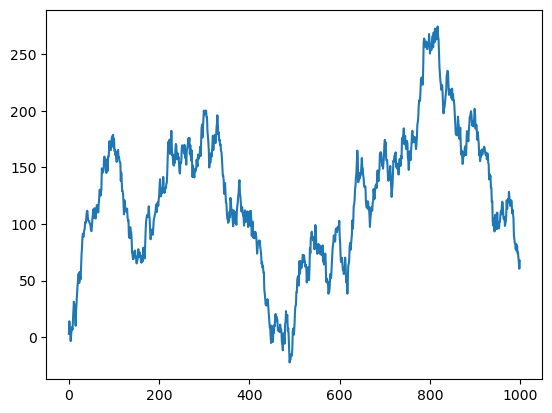

In [5]:
daily_profit['A'].cumsum().plot()

<Axes: >

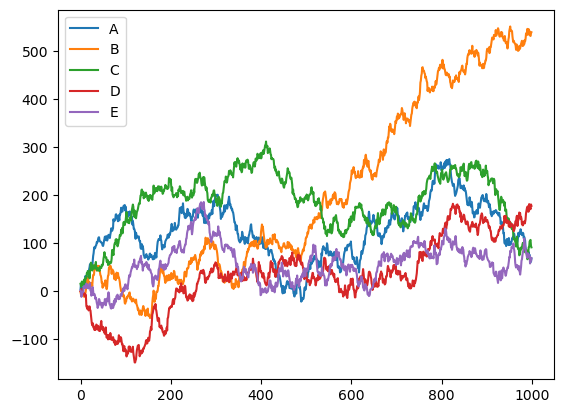

In [6]:
daily_profit.cumsum().plot()

## Problem 2 - Performance Stats 
- "rets" variable below is a DataFrame containing randomly generated, hypothetical daily returns. Rows represent days and columns represent symbols.
- Please complete the function "compute_stats".
- compute_stats takes as input rets and returns a new DataFrame (stats) containing performance stats as specified below. rows of the result should be symbols and columns the performance stat label.
    1. "avg": average return (annualized)
    2. "vol": volatility (annualized)
    3. "sharpe": sharpe ratio (annualzied)
    4. "hit_rate": percent of returns which are positive
- Plot the sharpe ratios in "stats" in ascending order.

In [10]:
import numpy as np 
import pandas as pd 

np.random.seed(5)
rets = np.random.normal(0.05/252,0.1/np.sqrt(252), (1000,5))
columns = ['A','B','C','D','E']
rets = pd.DataFrame(rets,columns = columns)

In [13]:
num_days = 252
rets_avg = rets.mean() * num_days
print(rets_avg)

A    0.028730
B    0.120800
C    0.018690
D    0.051331
E    0.013511
dtype: float64


In [14]:
num_days = 252
rets_vol = rets.std() * np.sqrt(num_days)
print(rets_vol)

A    0.101799
B    0.099772
C    0.103599
D    0.100662
E    0.101800
dtype: float64


In [15]:
rets_sharpe = rets_avg / rets_vol
print(rets_sharpe)

A    0.282224
B    1.210766
C    0.180409
D    0.509934
E    0.132720
dtype: float64


In [16]:
rets_hit = (rets > 0 ).mean()
print(rets_hit)

A    0.521
B    0.520
C    0.514
D    0.518
E    0.513
dtype: float64


        avg       vol    sharpe  hit_rate
A  0.028730  0.101799  0.282224     0.521
B  0.120800  0.099772  1.210766     0.520
C  0.018690  0.103599  0.180409     0.514
D  0.051331  0.100662  0.509934     0.518
E  0.013511  0.101800  0.132720     0.513


<Axes: title={'center': 'Sharpe Ratios (Ascending)'}>

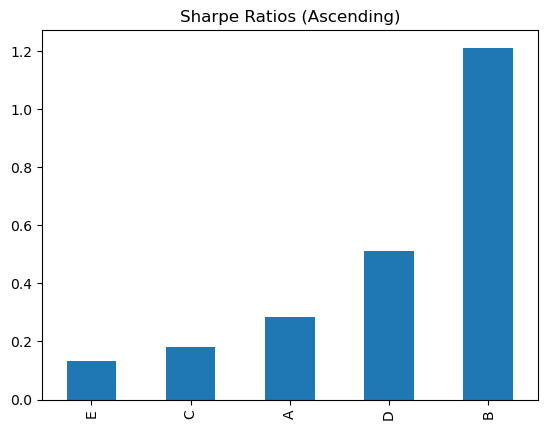

In [21]:
def compute_stats(rets):
    # fill out the body here
    # return a DataFrame "stats"
    # columns should be performance stat label
    # rows should be symbols

    num_days = 252 
    
    rets_avg = rets.mean() * num_days
    rets_vol = rets.std() * np.sqrt(num_days) 
    rets_sharpe = rets_avg / rets_vol
    rets_hit = (rets > 0 ).mean()

    stats = pd.DataFrame({
        "avg": rets_avg,
        "vol": rets_vol,
        "sharpe": rets_sharpe,
        "hit_rate": rets_hit
    })
    
    return stats

stats = compute_stats(rets)

print(stats)

stats["sharpe"].sort_values().plot(kind="bar", title="Sharpe Ratios (Ascending)")

## Problem 3 - Simple Reversal Signal
- "rets" variable below is a DataFrame containing randomly generated, hypothetical daily returns. Rows represent days and columns represent symbols
- Please complete the function "reversal_signal"
- reversal_signal takes as input rets and returns a new DataFrame (signal) which has the same rows/columns as rets. The values of signal are 1 if the symbol had the worst return that day, -1 if it had the best return, and 0 otherwise. 
- plot the value of signal through time for "A"

Hint: Try to construct a boolean DataFrame first and then convert it to an integer DataFrame

In [ ]:
import numpy as np 
import pandas as pd 

np.random.seed(5)
rets = np.random.normal(0.05/252,0.1/np.sqrt(252), (1000,5))
columns = ['A','B','C','D','E']
rets = pd.DataFrame(rets,columns = columns)

In [37]:
### signal = pd.DataFrame(0, index=rets.index, columns=rets.columns)
### signal.shape
### print(signal[:10])

In [39]:
minimum_value = rets.min(axis=1)
maximum_value = rets.max(axis=1)
worst_signal = rets.eq(minimum_value, axis=0)
best_signal  = rets.eq(maximum_value, axis=0)
signal = worst_signal.astype(int) - best_signal.astype(int)
print(signal)


     A  B  C  D  E
0    0  1 -1  0  0
1   -1  1  0  0  0
2    0  0  0 -1  1
3    0  0 -1  1  0
4    1  0  0  0 -1
..  .. .. .. .. ..
995  0  0 -1  1  0
996  0  0 -1  0  1
997  1  0  0  0 -1
998  0  0  1 -1  0
999 -1  0  0  1  0

[1000 rows x 5 columns]


In [41]:
def reversal_signal(rets):
    # fill out the body here
    # return a DataFrame "signal"
    # signal has same index/columns as rets
    # the value in signal is  1 if the symbol had the worst return on
    # a particular day, -1 if it had the best, and 0 otherwise
    minimum_value = rets.min(axis=1)
    maximum_value = rets.max(axis=1)
    worst_signal = rets.eq(minimum_value, axis=0)
    best_signal  = rets.eq(maximum_value, axis=0)
    signal = worst_signal.astype(int) - best_signal.astype(int)
    return signal
signal = reversal_signal(rets)

<Axes: >

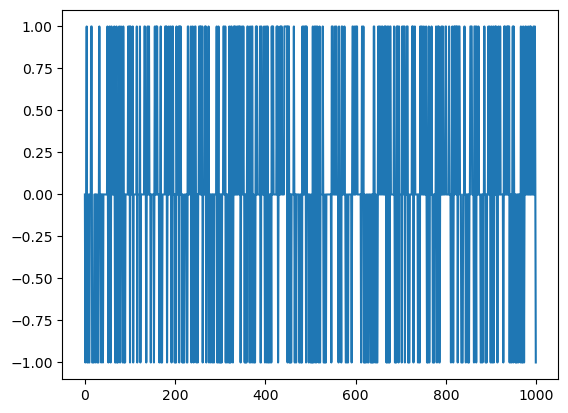

In [42]:
signal['A'].plot()